# STAT 7220 - Midterm Exam
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: March 6, 2026**

**PART 1 INSTRUCTIONS:** Suppose you are a video game controller manufacturer interested in estimating the perceived comfort level of controller grips. To achieve this, you decide to conduct an experiment to assess different material types used for the controller grips (plastic, rubber, silicone, and metal). 10 prototypes of each grip type are manufactured and given to professional gamers (who all play the same game -- Apex Legends) to test. The gamers use the controllers regularly for one month and then rate the comfort level on a scale from 1 - 10 with greater scores indicating a greater level of perceived comfort (one decimal allowed). The data from this experiment are stored in the Video Game Controllers.xlsx file. With these data, your tasks are:


In [4]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "cmuriithi"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
    print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
    print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

today_dir = "Assignments/Midterm-Exam"
if os.path.exists(today_dir):
    os.chdir(today_dir)
    print(f"📂 Changed directory to: {os.getcwd()}")
else:
    print(f"❌ ERROR: Directory '{today_dir}' not found in {os.getcwd()}. Please check the directory name or path within the repository.")
    print("Listing contents of current directory for debugging:")
    print(os.listdir('.'))

✅ Already inside repo folder: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/cmuriithi/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/Midterm-Exam


**Question 1.** Briefly define the objective of this experiment

This experiment's objective is to assess and contrast the perceived comfort levels of four distinct materials (plastic, rubber, silicone, and meta) that are used to make video game controller grips. The experiment seeks to ascertain whether there is a statistically significant difference in comfort based on the type of material and which material offers the highest level of user satisfaction by examining the comfort ratings (on a scale of 1 to 10) given by professional gamers after a month of consistent use.

**Question 2.** Specify the outcome variable



- **Dependent Variable:** Comfort

**Question 3.** Specify the independent variable. What are some possible lurking variables?



- **Independent Variable:** Material

- Multiple different possible lurking variables can when assessing the controller grip such as the grip style, the gamer's hand size, previous preference using rubber grips, etc.

**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.



- All of the participants are playing the same game leads to less variation to lead to similar interaction to the conroller. Lurking variables are treated randomly as well to settle any discrepancies in comfort are due to the material itself and not outside influences. Overall,  a CRD is the simplest method for comparing several treatment levels.

**Question 5.** State the null and alternative hypotheses for this experiment.

- ($H_0$):  $\mu_{\text{plastic}} = \mu_{\text{rubber}} = \mu_{\text{silicone}} = \mu_{\text{metal}}$

- ($H_a$): At least one of the mean comfort levels is different from the others.

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?



          count  mean  median       std  min  max
Material                                         
Metal        10  5.39    5.25  0.877433  4.0  6.5
Plastic      10  5.93    5.95  0.620125  4.6  6.8
Rubber       10  6.23    6.40  0.702456  4.9  7.5
Silicone     10  7.63    7.90  0.700872  6.6  8.4


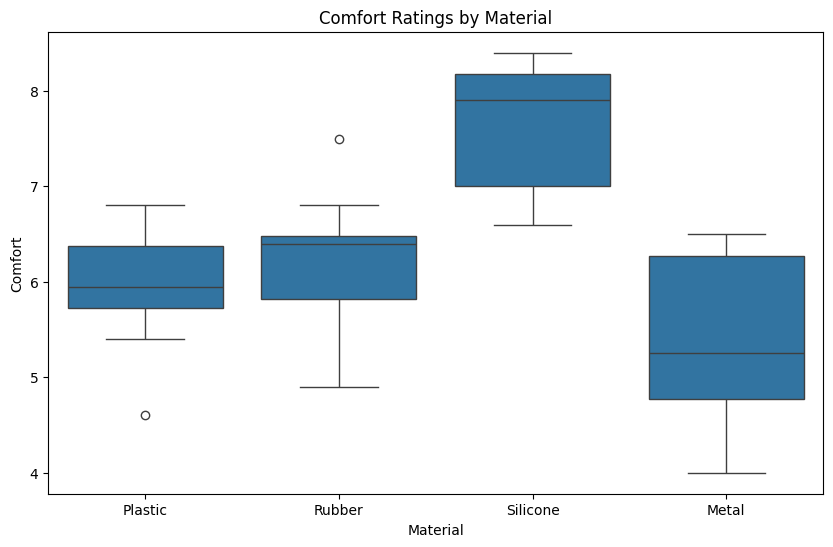

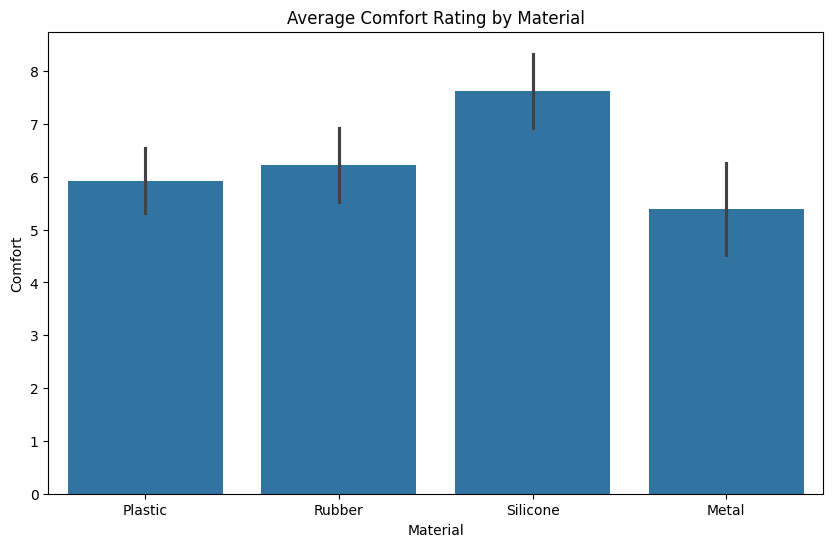

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the data
VG = pd.read_excel('Video Game Controllers.xlsx')

# Summary Statistics
summary_stats = VG.groupby('Material')['Comfort'].agg(['count', 'mean', 'median', 'std', 'min', 'max'])
print(summary_stats)

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x='Material', y='Comfort', data=VG)
plt.title('Comfort Ratings by Material')
plt.savefig('comfort_boxplot.png')
plt.show()

# Bar chart of means
plt.figure(figsize=(10, 6))
sns.barplot(x='Material', y='Comfort', data=VG, errorbar='sd') # ci='sd' is deprecated, use errorbar='sd'
plt.title('Average Comfort Rating by Material')
plt.savefig('comfort_barplot.png')
plt.show()

- The results of this exploratory analysis more strongly support the alternative hypothesis ($H_a$).

- The means vary significantly between the groups, ranging from 5.39 to 7.63. The boxplot demonstrates how the distribution of silicone is nearly completely distinct from that of the other materials, especially plastic and metal. The differences in the centers are more likely to be statistically significant rather than the result of chance because the variability is comparatively constant across groups.

**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using **both** a testing and visual method. Do the results of the normality test(s) support the assumption of normality?



Shapiro-Wilk p-value: 0.3874084700249114


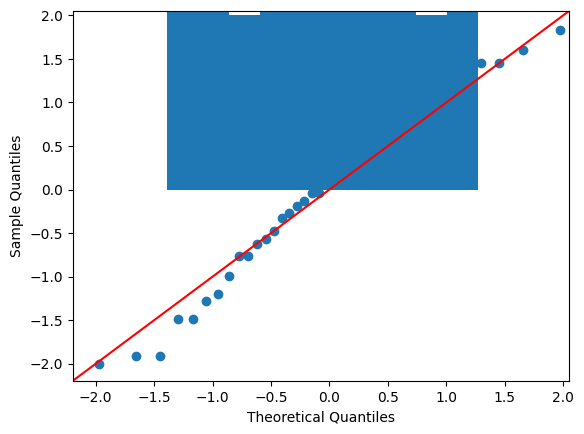

In [19]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
import matplotlib.pyplot as plt

# Build ANOVA model
model = ols('Comfort ~ C(Material)', data=VG).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# Extract residuals
residuals = model.resid

# Shapiro-Wilk Test
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk p-value: {shapiro_p}")

# Visual Methods
sm.qqplot(residuals, line='45', fit=True)
plt.savefig('qq_plot.png')

plt.hist(residuals, bins=10)
plt.savefig('residuals_hist.png')

- Since the $p \text{-value}$ ($0.3874$) of the Shapiro-Wilk test is greater than the standard significance level of $\alpha = 0.05$, we fail to reject the null hypothesis to suggest that the residuals are consistent with a normal distribution.

- The Q-Q plot displays the distribution of the residuals against the theoretical quantiles of a normal distribution. In our case, the data points fall closely along the 45-degree reference line, indicating normality.

- The results of both the statistical test and the visual methods strongly support the assumption of normality. The Shapiro-Wilk test was non-significant, and the visual plots show no major departures from the normal distribution.

**Question 8.** Test the assumption of homogeneity of variance using **both** a testing and visual method. Do the results of the test(s) support the assumption of homogeneity of variance?



**Question 9.** Report the F-statistic and its associated p-value for the test for the treatment factor. Which of our two hypotheses is more strongly supported? Why?



**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which material types are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.



**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses. Additionally, include potential limitations of this experiment and suggestions for future experimentation.



**PART 2 INSTRUCTIONS:** The same video game controller manufacturing company is now trying to get into the business of creating virtual reality/artificial intelligence content for education. Specifically, they want to build a VR experience to simulate working with elderly patients at a healthcare facility to better prepare nursing students for potential careers in working with elderly patients. To test the VR's effectiveness, a group of 40 undergraduate nursing students were randomly and equally assigned to either a class session utilizing the VR or a class session using a traditional technique for teaching strategies for working with elderly patients. At the end of the class session, a 50 question quiz was given to both groups which measures attitudes toward elderly people. Scores range from 0-50 with greater scores indicating more favorable attitudes toward elderly people and vice versa. However, some students in the group have had prior working experience with elderly people which may have an effect on the quiz outcome. So in the experiment, we document which students have had prior working experience with elderly people and which haven't. The results of the experiment are contained in the `Nursing VR Study.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment


**Question 2.** Specify the outcome variable



**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?



**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.



**Question 5.** State the null and alternative hypotheses for this experiment.



**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?



**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?



**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?



**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?



**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.



**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations of this experiment and suggestions for future experimentation.



**PART 3 INSTRUCTIONS:** Please briefly respond to the following questions:

**Question 1.** Give a reason why one-factor CRD wouldn't generally be appropriate for studies involving human participants.

**Question 2.** What is the purpose of post-hoc tests?

**Question 3.** Explain the difference between RBD and LSD.

**Question 4.** Explain why randomization is important in designing experiments.

**Question 5.** Explain why replication is important in designing experiments.